## Image Segmentation
Part 1 of image segment analysis, segmenting images with Python. Code from opensourceoptions.com resources and tutorial. https://opensourceoptions.com/python-geographic-object-based-image-analysis-geobia/

In [23]:
# Importing Packages
import numpy as np
import pandas as pd
from skimage import exposure
from skimage.segmentation import quickshift, slic, mark_boundaries
from sklearn.metrics import confusion_matrix
import time
import scipy
import matplotlib.pyplot as plt
from osgeo import gdal
from osgeo import ogr
from osgeo import osr
from osgeo import gdal_array
import os
import geopandas as gpd
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from rasterio.transform import Affine

In [2]:
os.chdir('/home/jovyan/project/trees_n_shrimps')
camau2026_fn = 'ca_mau_2026_48PVQ.tif'
camau2017_fn = 'ca_mau_2017_48PVQ.tif'
# verify files exist
for fn in [camau2026_fn, camau2017_fn]:
    print(fn, 'exists:', os.path.exists(fn))

ca_mau_2026_48PVQ.tif exists: True
ca_mau_2017_48PVQ.tif exists: True


In [3]:
# Open the dataset 2026
driverTiff = gdal.GetDriverByName('GTiff')
camau2026_ds = gdal.Open(camau2026_fn)

# Check it opened correctly
if camau2026_ds is None:
    raise FileNotFoundError(f"Could not open file: {camau2026_fn}")

nbands = camau2026_ds.RasterCount
print('bands', camau2026_ds.RasterCount, 'rows', camau2026_ds.RasterYSize, 'columns', camau2026_ds.RasterXSize)

# Read all bands into a stacked array
band_data2026 = []
for i in range(1, nbands + 1):
    band = camau2026_ds.GetRasterBand(i).ReadAsArray()
    band_data2026.append(band)

band_data2026 = np.dstack(band_data2026)
band_data2026 = np.nan_to_num(band_data2026, nan=np.nanmedian(band_data2026))
print('Array shape:', band_data2026.shape)  # (rows, cols, bands)

bands 7 rows 1660 columns 2202


/opt/conda/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Array shape: (1660, 2202, 7)


In [4]:
# Open the dataset 2017
driverTiff = gdal.GetDriverByName('GTiff')
camau2017_ds = gdal.Open(camau2017_fn)

# Check it opened correctly
if camau2017_ds is None:
    raise FileNotFoundError(f"Could not open file: {camau2017_fn}")

nbands = camau2017_ds.RasterCount
print('bands', camau2017_ds.RasterCount, 'rows', camau2017_ds.RasterYSize, 'columns', camau2017_ds.RasterXSize)

# Read all bands into a stacked array
band_data2017 = []
for i in range(1, nbands + 1):
    band = camau2017_ds.GetRasterBand(i).ReadAsArray()
    band_data2017.append(band)

band_data2017 = np.dstack(band_data2017)
band_data2017 = np.nan_to_num(band_data2017, nan=np.nanmedian(band_data2017))

print('Array shape:', band_data2017.shape)  # (rows, cols, bands)

bands 7 rows 1660 columns 2202
Array shape: (1660, 2202, 7)


In [5]:
# Segmentation done using scikit-image. 2026

# scale image values from 0.0 - 1.0
img2026 = exposure.rescale_intensity(band_data2026)

# do segmentation multiple options with quickshift and slic
# figure out which option works best (see examples right below)
seg_start = time.time()
# segments2026 = quickshift(img2026, convert2lab=False)
# segments2026 = quickshift(img2026, ratio=0.8, convert2lab=False)
#segments2026 = quickshift(img2026, ratio=0.6, max_dist=5, convert2lab=False)
# segments2026 = slic(img2026, n_segments=100000, compactness=0.1)
#segments2026 = slic(img2026, n_segments=10000, compactness=0.3)
segments2026 = slic(img2026, n_segments=50000, compactness=0.1)
print('segments complete', time.time() - seg_start)

# save segments to raster
segments2026_fn = 'segments2026.tif'
segments2026_ds = driverTiff.Create(segments2026_fn, camau2026_ds.RasterXSize, camau2026_ds.RasterYSize,
                                1, gdal.GDT_Float32)
segments2026_ds.SetGeoTransform(camau2026_ds.GetGeoTransform())
segments2026_ds.SetProjection(camau2026_ds.GetProjectionRef())
segments2026_ds.GetRasterBand(1).WriteArray(segments2026)
segments2026_ds = None

print('Unique segments 2026:', len(np.unique(segments2026)))
print('Image shape 2026:', img2026.shape)
print('Segments shape 2026:', segments2026.shape)
print('Segments min/max 2026:', segments2026.min(), segments2026.max())

segments complete 4.256836891174316
Unique segments 2026: 40385
Image shape 2026: (1660, 2202, 7)
Segments shape 2026: (1660, 2202)
Segments min/max 2026: 1 40385


In [6]:
# Segmentation done using scikit-image. 2017

# scale image values from 0.0 - 1.0
img2017 = exposure.rescale_intensity(band_data2017)



# do segmentation multiple options with quickshift and slic
# figure out which option works best (see examples right below)
seg_start = time.time()
# segments2017 = quickshift(img2017, convert2lab=False)
# segments2017 = quickshift(img2017, ratio=0.8, convert2lab=False)
#segments2017 = quickshift(img2017, ratio=0.6, max_dist=5, convert2lab=False)
#segments2017 = slic(img2017, n_segments=10000, compactness=0.3)
# segments2017 = slic(img2017, n_segments=500000, compactness=0.01)
segments2017 = slic(img2017, n_segments=50000, compactness=0.1)
print('segments complete', time.time() - seg_start)

# save segments to raster
segments2017_fn = 'segments2017.tif'
segments2017_ds = driverTiff.Create(segments2017_fn, camau2017_ds.RasterXSize, camau2017_ds.RasterYSize,
                                1, gdal.GDT_Float32)
segments2017_ds.SetGeoTransform(camau2017_ds.GetGeoTransform())
segments2017_ds.SetProjection(camau2017_ds.GetProjectionRef())
segments2017_ds.GetRasterBand(1).WriteArray(segments2017)
segments2017_ds = None

print('Unique segments 2017:', len(np.unique(segments2017)))
print('Image shape 2017:', img2017.shape)
print('Segments shape 2017:', segments2017.shape)
print('Segments min/max 2017:', segments2017.min(), segments2017.max())

segments complete 4.352476119995117
Unique segments 2017: 39845
Image shape 2017: (1660, 2202, 7)
Segments shape 2017: (1660, 2202)
Segments min/max 2017: 1 39845


Text(0.5, 1.0, '2026 Segmentation result: 40385 segments')

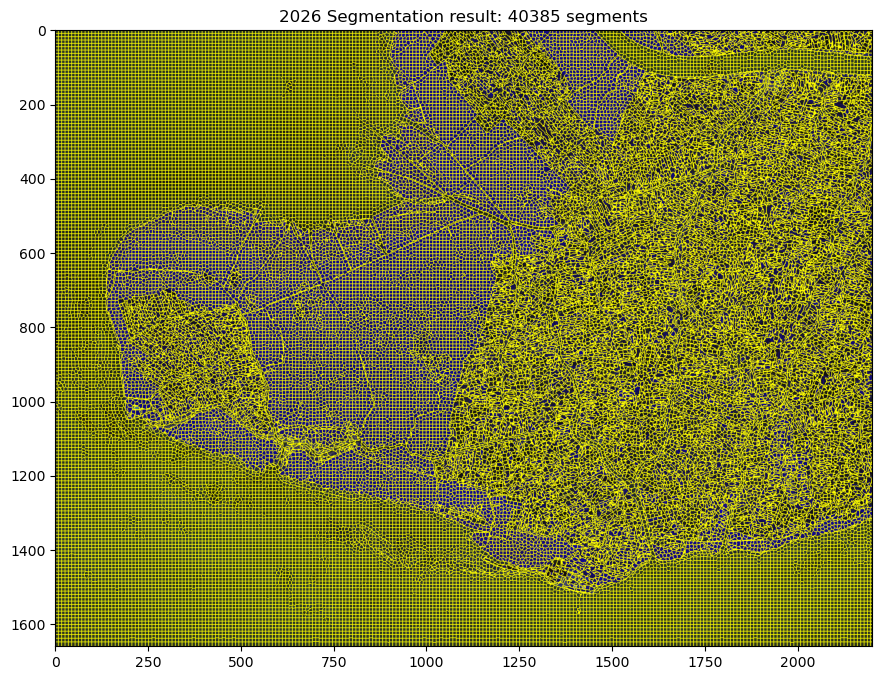

In [7]:
rgb = exposure.rescale_intensity(band_data2026[:, :, :3].astype(float))
plt.figure(figsize=(12, 8))
plt.imshow(mark_boundaries(rgb, segments2026))
plt.title(f'2026 Segmentation result: {len(np.unique(segments2026))} segments')

Text(0.5, 1.0, '2017 Segmentation result: 39845 segments')

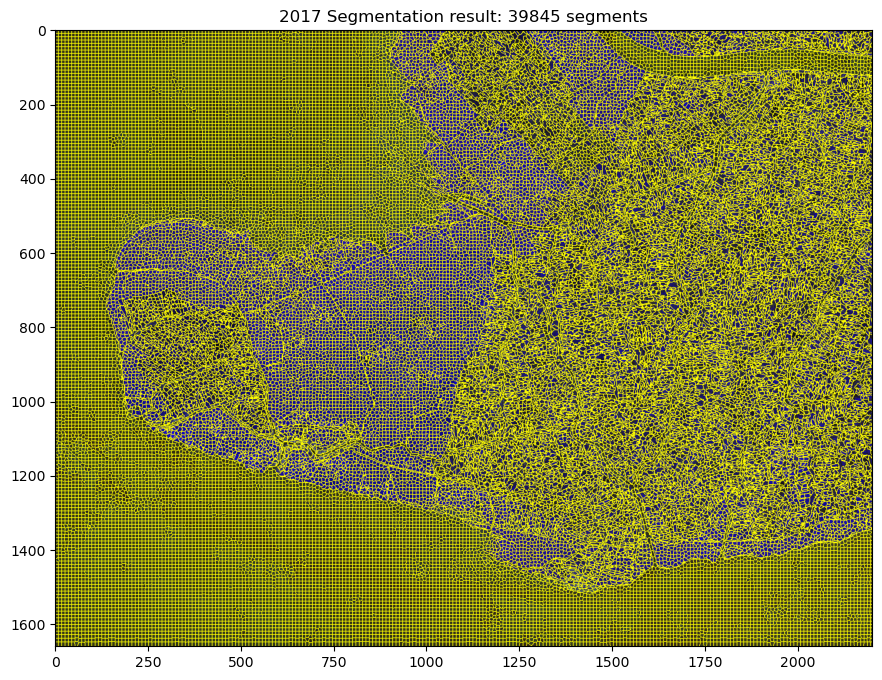

In [8]:
rgb = exposure.rescale_intensity(band_data2017[:, :, :3].astype(float))
plt.figure(figsize=(12, 8))
plt.imshow(mark_boundaries(rgb, segments2017))
plt.title(f'2017 Segmentation result: {len(np.unique(segments2017))} segments')

In [9]:
# Describing each segment based on spectral properties: 
# spectral properties = variables that will classify each segment as a land cover type.

# Function that returns the min, max, mean, variance, skewness, and kurtois for each band in a given array of pixels.
def segment_features(segment_pixels):
    features = []
    npixels, nbands = segment_pixels.shape
    for b in range(nbands):
        stats = scipy.stats.describe(segment_pixels[:, b])
        band_stats = list(stats.minmax) + list(stats)[2:]
        if npixels == 1:
            # in this case the variance = nan, change it 0.0
            band_stats[3] = 0.0
        features += band_stats
    return features

In [10]:
# Makes a list of segment ID numbers and the pixels for each are passed to segment_features.
# Statistics from segment_features are stored in objects list, and object_id stored in a separate list.
# May take several hours to run, depending on setup. 
#Note from Will- actually didn't take that long to run, maybe 15 mins

segment2026_ids = np.unique(segments2026)
objects2026 = []
object_ids2026 = []
for id in segment2026_ids:
    segment_pixels = img2026[segments2026 == id]
    object_features = segment_features(segment_pixels)
    objects2026.append(object_features)
    object_ids2026.append(id)

In [11]:
segment2017_ids = np.unique(segments2017)
objects2017 = []
object_ids2017 = []
for id in segment2017_ids:
    segment_pixels = img2017[segments2017 == id]
    object_features = segment_features(segment_pixels)
    objects2017.append(object_features)
    object_ids2017.append(id)

In [12]:
#Create pandas dataframe, set segment ID as index
df_camau_2026 = pd.DataFrame(objects2026)
df_camau_2026["segment_id"] = object_ids2026
df_camau_2026 = df_camau_2026.set_index("segment_id")

In [13]:
#Create pandas dataframe, set segment ID as index
df_camau_2017 = pd.DataFrame(objects2017)
df_camau_2017["segment_id"] = object_ids2017
df_camau_2017 = df_camau_2017.set_index("segment_id")

In [14]:
#Give column names from stats and bands; number of columns = # stats x # bands
stats = ["min","max","mean","var","skew","kurt"]
bands = ["B03","B04","B08","B11","NDVI","NDWI","CMRI"]

columns2026 = []
for b in bands:
    for s in stats:
        columns2026.append(f"{b}_{s}")

df_camau_2026.columns = columns2026

In [15]:
columns2017 = []
for b in bands:
    for s in stats:
        columns2017.append(f"{b}_{s}")

df_camau_2017.columns = columns2017

In [3]:
# read shapefile to geopandas geodataframe
gdf2017 = gpd.read_file('camau_trainingobject/camau_2017trainingobject.shp')
gdf2017 = gdf2017.dropna(subset=['Class_ID'])

In [4]:
gdf2026 = gpd.read_file('camau_trainingobject/camau_2026trainingobject.shp')
gdf2026 = gdf2026.dropna(subset=['Class_ID'])

In [5]:
class_names = gdf2017['Class'].unique()
class_ids = gdf2017['Class_ID'].unique()
print('class names', class_names)
print('class ids', class_ids)

# save lookup table
df2017 = pd.DataFrame({'label': class_names, 'id': class_ids})
df2017.to_csv('class_lookup2017.csv', index=False)

# map IDs onto geodataframe
gdf2017['id'] = gdf2017['Class'].map(dict(zip(class_names, class_ids)))
print('gdf with ids', gdf2017.head())

# 70/30 train/test split
gdf_train2017 = gdf2017.sample(frac=0.7, random_state=42)
gdf_test2017 = gdf2017.drop(gdf_train2017.index)
print('gdf shape', gdf2017.shape, 'training shape', gdf_train2017.shape, 'test', gdf_test2017.shape)

gdf_train2017.to_file('gdf_train2017.shp')
gdf_test2017.to_file('gdf_test2017.shp')

class names ['Water' 'Mangrove-integrated pond' 'Pond' 'Built up/bare' 'Mangrove']
class ids [1. 2. 3. 5. 4.]
gdf with ids     Id  Class  Class_ID                                           geometry  \
0  0.0  Water       1.0  POLYGON ((479877.738 956396.259, 480084.193 95...   
1  0.0  Water       1.0  POLYGON ((478526.77 956786.375, 478844.382 956...   
2  0.0  Water       1.0  POLYGON ((484741.927 958368.309, 484786.336 95...   
3  0.0  Water       1.0  POLYGON ((483665.472 955345.702, 483692.538 95...   
4  0.0  Water       1.0  POLYGON ((483824.942 953964.727, 483914.527 95...   

    id  
0  1.0  
1  1.0  
2  1.0  
3  1.0  
4  1.0  
gdf shape (170, 5) training shape (119, 5) test (51, 5)


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


In [19]:
# map IDs onto geodataframe
gdf2026['id'] = gdf2026['Class'].map(dict(zip(class_names, class_ids)))
print('gdf with ids', gdf2026.head())

# 70/30 train/test split
gdf_train2026 = gdf2026.sample(frac=0.7, random_state=42)
gdf_test2026 = gdf2026.drop(gdf_train2026.index)
print('gdf shape', gdf2026.shape, 'training shape', gdf_train2026.shape, 'test', gdf_test2026.shape)

gdf_train2026.to_file('gdf_train2026.shp')
gdf_test2026.to_file('gdf_test2026.shp')

gdf with ids     Id  Class  Class_ID                                           geometry  \
0  0.0  Water         1  POLYGON ((479877.738 956396.259, 480084.193 95...   
1  0.0  Water         1  POLYGON ((478526.77 956786.375, 478844.382 956...   
2  0.0  Water         1  POLYGON ((484741.927 958368.309, 484786.336 95...   
3  0.0  Water         1  POLYGON ((483665.472 955345.702, 483692.538 95...   
4  0.0  Water         1  POLYGON ((483824.942 953964.727, 483914.527 95...   

    id  
0  1.0  
1  1.0  
2  1.0  
3  1.0  
4  1.0  
gdf shape (171, 5) training shape (120, 5) test (51, 5)


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


In [20]:

# Open your training polygons
train_fn2017 = 'gdf_train2017.shp'
train_ds2017 = ogr.Open(train_fn2017)
lyr2017 = train_ds2017.GetLayer()

# Check what fields are available
lyr_defn = lyr2017.GetLayerDefn()
field_names = [lyr_defn.GetFieldDefn(i).GetName() for i in range(lyr_defn.GetFieldCount())]
print('Available fields:', field_names)

# Create raster in memory
driver = gdal.GetDriverByName('MEM')
target_ds2017 = driver.Create('', camau2017_ds.RasterXSize, camau2017_ds.RasterYSize, 1, gdal.GDT_UInt16)
target_ds2017.SetGeoTransform(camau2017_ds.GetGeoTransform())
target_ds2017.SetProjection(camau2017_ds.GetProjection())

# Rasterize using 'Class_ID'
options = ['ATTRIBUTE=Class_ID']
gdal.RasterizeLayer(target_ds2017, [1], lyr2017, options=options)

data2017 = target_ds2017.GetRasterBand(1).ReadAsArray()
print('min', data2017.min(), 'max', data2017.max())
print('Unique classes rasterized:', np.unique(data2017))

Available fields: ['Id', 'Class', 'Class_ID', 'id_1']
min 0 max 5
Unique classes rasterized: [0 1 2 3 4 5]


In [21]:
# Open your training polygons
train_fn2026 = 'gdf_train2026.shp'
train_ds2026 = ogr.Open(train_fn2026)
lyr2026 = train_ds2026.GetLayer()

# Check what fields are available
lyr_defn = lyr2026.GetLayerDefn()
field_names = [lyr_defn.GetFieldDefn(i).GetName() for i in range(lyr_defn.GetFieldCount())]
print('Available fields:', field_names)

# Create raster in memory
driver = gdal.GetDriverByName('MEM')
target_ds2026 = driver.Create('', camau2026_ds.RasterXSize, camau2026_ds.RasterYSize, 1, gdal.GDT_UInt16)
target_ds2026.SetGeoTransform(camau2026_ds.GetGeoTransform())
target_ds2026.SetProjection(camau2026_ds.GetProjection())

# Rasterize using 'Class_ID'
options = ['ATTRIBUTE=Class_ID']
gdal.RasterizeLayer(target_ds2026, [1], lyr2026, options=options)

data2026 = target_ds2026.GetRasterBand(1).ReadAsArray()
print('min', data2026.min(), 'max', data2026.max())
print('Unique classes rasterized:', np.unique(data2026))

Available fields: ['Id', 'Class', 'Class_ID', 'id_1']
min 0 max 5
Unique classes rasterized: [0 1 2 3 4 5]


In [22]:
ground_truth2017 = target_ds2017.GetRasterBand(1).ReadAsArray()
classes = np.unique(ground_truth2017)[1:] 
print('class values', classes)

segments_per_class2017 = {}
for klass in classes:
    segments_of_class = segments2017[ground_truth2017 == klass]  
    segments_per_class2017[klass] = set(segments_of_class)       
    print("Training segments for class", klass, ":", len(segments_of_class))

intersection = set()
accum = set()
for class_segments in segments_per_class2017.values():
    intersection |= accum.intersection(class_segments)
    accum |= class_segments

print(f"Removing {len(intersection)} ambiguous segments that span multiple classes")

# remove conflicted segments from all classes
segments_per_class2017_clean = {}
for klass in classes:
    segments_per_class2017_clean[klass] = segments_per_class2017[klass] - intersection
    print(f"Class {klass}: {len(segments_per_class2017[klass])} -> {len(segments_per_class2017_clean[klass])} segments after cleaning")

segments_per_class2017 = segments_per_class2017_clean

intersection = set()
accum = set()
for class_segments in segments_per_class2017.values():
    intersection |= accum.intersection(class_segments)
    accum |= class_segments
assert len(intersection) == 0, "Segment(s) represent multiple classes"

class values [1 2 3 4 5]
Training segments for class 1 : 13492
Training segments for class 2 : 24056
Training segments for class 3 : 11120
Training segments for class 4 : 15842
Training segments for class 5 : 2232
Removing 4 ambiguous segments that span multiple classes
Class 1: 249 -> 249 segments after cleaning
Class 2: 528 -> 524 segments after cleaning
Class 3: 226 -> 222 segments after cleaning
Class 4: 306 -> 306 segments after cleaning
Class 5: 69 -> 69 segments after cleaning


In [23]:
ground_truth2026 = target_ds2026.GetRasterBand(1).ReadAsArray()
classes = np.unique(ground_truth2026)[1:] 
print('class values', classes)

segments_per_class2026 = {}
for klass in classes:
    segments_of_class = segments2026[ground_truth2026 == klass]  
    segments_per_class2026[klass] = set(segments_of_class)       
    print("Training segments for class", klass, ":", len(segments_of_class))

intersection = set()
accum = set()
for class_segments in segments_per_class2026.values():
    intersection |= accum.intersection(class_segments)
    accum |= class_segments

print(f"Removing {len(intersection)} ambiguous segments that span multiple classes")

# remove conflicted segments from all classes
segments_per_class2026_clean = {}
for klass in classes:
    segments_per_class2026_clean[klass] = segments_per_class2026[klass] - intersection
    print(f"Class {klass}: {len(segments_per_class2026[klass])} -> {len(segments_per_class2026_clean[klass])} segments after cleaning")

segments_per_class2026 = segments_per_class2026_clean

intersection = set()
accum = set()
for class_segments in segments_per_class2026.values():
    intersection |= accum.intersection(class_segments)
    accum |= class_segments
assert len(intersection) == 0, "Segment(s) represent multiple classes"

class values [1 2 3 4 5]
Training segments for class 1 : 13943
Training segments for class 2 : 23661
Training segments for class 3 : 12784
Training segments for class 4 : 7183
Training segments for class 5 : 2284
Removing 8 ambiguous segments that span multiple classes
Class 1: 259 -> 256 segments after cleaning
Class 2: 544 -> 539 segments after cleaning
Class 3: 273 -> 268 segments after cleaning
Class 4: 157 -> 157 segments after cleaning
Class 5: 87 -> 84 segments after cleaning


In [24]:
### Classify the Image
train_img2017 = np.copy(segments2017)
threshold = train_img2017.max() + 1
for klass in classes:
    class_label = threshold + klass
    for segment_id in segments_per_class2017[klass]:
        train_img2017[train_img2017 == segment_id] = class_label
train_img2017[train_img2017 <= threshold] = 0
train_img2017[train_img2017 > threshold] -= threshold

segment_ids = object_ids2017
objects = objects2017

training_objects = []
training_labels = []
for klass in classes:
    class_train_object = [v for i, v in enumerate(objects) if segment_ids[i] in segments_per_class2017[klass]]
    training_labels += [klass] * len(class_train_object)
    training_objects += class_train_object
    print('Training objects for class', klass, ':', len(class_train_object))

classifier = RandomForestClassifier(n_jobs=-1)
classifier.fit(training_objects, training_labels)
print('Fitting Random Forest Classifier')

predicted = classifier.predict(objects)
print('Predicting Classifications')

clf2017 = np.copy(segments2017)
for segment_id, klass in zip(segment_ids, predicted):
    clf2017[clf2017 == segment_id] = klass
print('Prediction applied to numpy array')

nodata_val = camau2017_ds.GetRasterBand(1).GetNoDataValue()
print('Nodata value:', nodata_val)
nodata_mask = (band_data2017[:,:,0] == nodata_val)  # mask where first band == nodata
clf2017[nodata_mask] = -9999.0

print('Saving classification to raster with gdal')
clfds2017 = driverTiff.Create('classified_2017_try1.tif', camau2017_ds.RasterXSize, camau2017_ds.RasterYSize,
                          1, gdal.GDT_Float32)
clfds2017.SetGeoTransform(camau2017_ds.GetGeoTransform())
clfds2017.SetProjection(camau2017_ds.GetProjection())
clfds2017.GetRasterBand(1).SetNoDataValue(-9999.0)
clfds2017.GetRasterBand(1).WriteArray(clf2017)
clfds2017 = None
print('Done!')

Training objects for class 1 : 249
Training objects for class 2 : 524
Training objects for class 3 : 222
Training objects for class 4 : 306
Training objects for class 5 : 69
Fitting Random Forest Classifier
Predicting Classifications
Prediction applied to numpy array
Nodata value: None
Saving classification to raster with gdal
Done!


In [ ]:
### Classify the Image 2026
train_img2026 = np.copy(segments2026)
threshold = train_img2026.max() + 1
for klass in classes:
    class_label = threshold + klass
    for segment_id in segments_per_class2026[klass]:
        train_img2026[train_img2026 == segment_id] = class_label
train_img2026[train_img2026 <= threshold] = 0
train_img2026[train_img2026 > threshold] -= threshold

segment_ids = object_ids2026
objects = objects2026

training_objects = []
training_labels = []
for klass in classes:
    class_train_object = [v for i, v in enumerate(objects) if segment_ids[i] in segments_per_class2026[klass]]
    training_labels += [klass] * len(class_train_object)
    training_objects += class_train_object
    print('Training objects for class', klass, ':', len(class_train_object))

classifier = RandomForestClassifier(n_jobs=-1)
classifier.fit(training_objects, training_labels)
print('Fitting Random Forest Classifier')

predicted = classifier.predict(objects)
print('Predicting Classifications')

clf2026 = np.copy(segments2026)
for segment_id, klass in zip(segment_ids, predicted):
    clf2026[clf2026 == segment_id] = klass
print('Prediction applied to numpy array')

nodata_val = camau2026_ds.GetRasterBand(1).GetNoDataValue()
print('Nodata value:', nodata_val)
nodata_mask = (band_data2026[:,:,0] == nodata_val)  # mask where first band == nodata
clf2026[nodata_mask] = -9999.0

print('Saving classification to raster with gdal')
clfds2026 = driverTiff.Create('classified_2026_try1.tif', camau2026_ds.RasterXSize, camau2026_ds.RasterYSize,
                          1, gdal.GDT_Float32)
clfds2026.SetGeoTransform(camau2026_ds.GetGeoTransform())
clfds2026.SetProjection(camau2026_ds.GetProjection())
clfds2026.GetRasterBand(1).SetNoDataValue(-9999.0)
clfds2026.GetRasterBand(1).WriteArray(clf2026)
clfds2026 = None
print('Done!')

In [6]:
camau2017_classified_ds = gdal.Open("classified_2017_try1.tif")
camau2026_classified_ds = gdal.Open("classified_2026_try1.tif")
band17 = camau2017_classified_ds.GetRasterBand(1)
data17 = band17.ReadAsArray()
band26 = camau2026_classified_ds.GetRasterBand(1)
data26 = band26.ReadAsArray()

/opt/conda/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


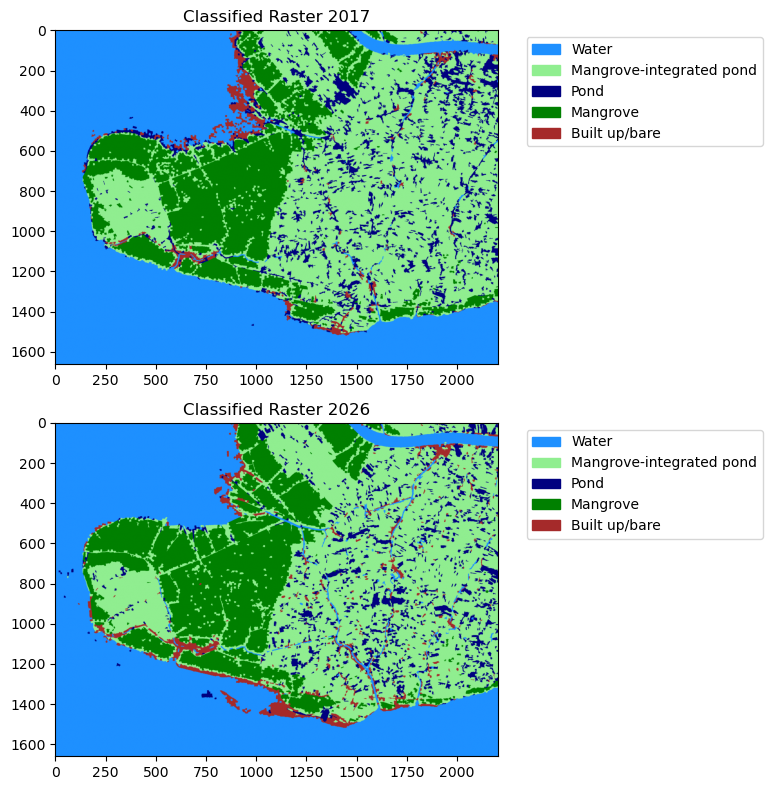

In [7]:
#plot for quick comparison
class_info = {
    1: ('dodgerblue',  'Water'),
    2: ('lightgreen', 'Mangrove-integrated pond'),
    3: ('navy',       'Pond'),
    4: ('green',     'Mangrove'),
    5: ('brown',      'Built up/bare'),
}

colors = [class_info[i][0] for i in range(1, 6)]
labels = [class_info[i][1] for i in range(1, 6)]

cmap = ListedColormap(colors)

fig, ax = plt.subplots(2,1,figsize=(10, 8))
ax[0].imshow(data17, cmap=cmap, vmin=0.5, vmax=5.5)
ax[1].imshow(data26, cmap=cmap, vmin=0.5, vmax=5.5)

# Legend
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax[0].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

ax[0].set_title('Classified Raster 2017')
ax[1].set_title('Classified Raster 2026')
plt.tight_layout()

In [8]:
#Comparison matrix
test2017_fn = 'gdf_test2017.shp'
test2017_ds = ogr.Open(test2017_fn)
lyr2017 = test2017_ds.GetLayer()

driver = gdal.GetDriverByName('MEM')
target2017_ds = driver.Create('', camau2017_classified_ds.RasterXSize, camau2017_classified_ds.RasterYSize, 1, gdal.GDT_UInt16)
target2017_ds.SetGeoTransform(camau2017_classified_ds.GetGeoTransform())
target2017_ds.SetProjection(camau2017_classified_ds.GetProjection())
options = ['ATTRIBUTE=Class_ID']
gdal.RasterizeLayer(target2017_ds, [1], lyr2017, options=options)

truth2017 = target2017_ds.GetRasterBand(1).ReadAsArray()

idx = np.nonzero(truth2017)

cm = metrics.confusion_matrix(truth2017[idx], data17[idx])

# pixel accuracy
print(cm)

print(cm.diagonal())
print(cm.sum(axis=0))

accuracy = cm.diagonal() / cm.sum(axis=0)
print(accuracy)

[[1836   68   50    0    0]
 [   0 7270  351  210    0]
 [   0 1900 3563    0    0]
 [   0  190    0 3648    0]
 [   2  232  299    0  782]]
[1836 7270 3563 3648  782]
[1838 9660 4263 3858  782]
[0.99891186 0.75258799 0.83579639 0.94556765 1.        ]


In [9]:
accuracy = cm.diagonal() / cm.sum(axis=0)
support = cm.sum(axis=0)
producer_acc = cm.diagonal() / cm.sum(axis=1)  # row-wise (recall)

summary = pd.DataFrame({
    'Class': class_names,
    "User's Acc (Precision)": accuracy.round(4),
    "Producer's Acc (Recall)": producer_acc.round(4),
    'True Positives': cm.diagonal(),
    'Total Predicted': support
})
summary = summary.set_index('Class')
print(summary.to_string())

# Overall accuracy
overall = np.trace(cm) / cm.sum()
print(f"\nOverall Accuracy: {overall:.4f}")

                          User's Acc (Precision)  Producer's Acc (Recall)  True Positives  Total Predicted
Class                                                                                                     
Water                                     0.9989                   0.9396            1836             1838
Mangrove-integrated pond                  0.7526                   0.9284            7270             9660
Pond                                      0.8358                   0.6522            3563             4263
Built up/bare                             0.9456                   0.9505            3648             3858
Mangrove                                  1.0000                   0.5947             782              782

Overall Accuracy: 0.8381


In [10]:
#Comparison matrix
test2026_fn = 'gdf_test2026.shp'
test2026_ds = ogr.Open(test2026_fn)
lyr2026 = test2026_ds.GetLayer()

driver = gdal.GetDriverByName('MEM')
target2026_ds = driver.Create('', camau2026_classified_ds.RasterXSize, camau2026_classified_ds.RasterYSize, 1, gdal.GDT_UInt16)
target2026_ds.SetGeoTransform(camau2026_classified_ds.GetGeoTransform())
target2026_ds.SetProjection(camau2026_classified_ds.GetProjection())
options = ['ATTRIBUTE=Class_ID']
gdal.RasterizeLayer(target2026_ds, [1], lyr2026, options=options)

truth2026 = target2026_ds.GetRasterBand(1).ReadAsArray()

idx = np.nonzero(truth2026)

cm = metrics.confusion_matrix(truth2026[idx], data26[idx])

# pixel accuracy
print(cm)

print(cm.diagonal())
print(cm.sum(axis=0))

accuracy = cm.diagonal() / cm.sum(axis=0)
print(accuracy)

[[ 1055    39    66     0    29]
 [    1  7236   796     2    15]
 [   13  3014  3107     0     5]
 [    0   550     0 11129     0]
 [   53   112    54     0  1388]]
[ 1055  7236  3107 11129  1388]
[ 1122 10951  4023 11131  1437]
[0.9402852  0.66076157 0.77230922 0.99982032 0.96590118]


In [11]:
accuracy = cm.diagonal() / cm.sum(axis=0)
support = cm.sum(axis=0)
producer_acc = cm.diagonal() / cm.sum(axis=1)  # row-wise (recall)

summary = pd.DataFrame({
    'Class': class_names,
    "User's Acc (Precision)": accuracy.round(4),
    "Producer's Acc (Recall)": producer_acc.round(4),
    'True Positives': cm.diagonal(),
    'Total Predicted': support
})
summary = summary.set_index('Class')
print(summary.to_string())

# Overall accuracy
overall = np.trace(cm) / cm.sum()
print(f"\nOverall Accuracy: {overall:.4f}")

                          User's Acc (Precision)  Producer's Acc (Recall)  True Positives  Total Predicted
Class                                                                                                     
Water                                     0.9403                   0.8873            1055             1122
Mangrove-integrated pond                  0.6608                   0.8989            7236            10951
Pond                                      0.7723                   0.5061            3107             4023
Built up/bare                             0.9998                   0.9529           11129            11131
Mangrove                                  0.9659                   0.8637            1388             1437

Overall Accuracy: 0.8343


In [12]:
#See which classes changes over time
class_ids   = [1, 2, 3, 4, 5]
nodata_value = 0  
valid_mask = (data17 != nodata_value) & (data26 != nodata_value)
gt = camau2017_classified_ds.GetGeoTransform()
pixel_area_ha = (gt[1]**2) / 10000

year1 = data17[valid_mask].astype(int)
year2 = data26[valid_mask].astype(int)

matrix_by_ha = pd.DataFrame(
    confusion_matrix(year1, year2, labels=class_ids) * pixel_area_ha,
    index=class_names,
    columns=class_names
)
matrix_by_ha.index.name   = "From (2017)"
matrix_by_ha.columns.name = "To (2026)"
print(matrix_by_ha.round(2))

To (2026)                    Water  Mangrove-integrated pond     Pond  \
From (2017)                                                             
Water                     13251.45                    153.15    61.48   
Mangrove-integrated pond    187.16                  10411.40  1580.26   
Pond                        137.72                   1846.97   408.26   
Built up/bare                46.13                    560.52     9.63   
Mangrove                     77.18                    166.12    17.27   

To (2026)                 Built up/bare  Mangrove  
From (2017)                                        
Water                            191.12    331.11  
Mangrove-integrated pond         766.75    366.83  
Pond                             148.44    148.82  
Built up/bare                   5210.84     38.63  
Mangrove                         193.73    242.23  


In [13]:
#Get basic summary of changes by class
summary = []
for label in class_names:
    idx    = list(class_names).index(label)
    gained = matrix_by_ha.iloc[:, idx].sum() - matrix_by_ha.iloc[idx, idx]
    lost   = matrix_by_ha.iloc[idx, :].sum() - matrix_by_ha.iloc[idx, idx]
    summary.append({"Class": label, "Gained (ha)": gained,
                    "Lost (ha)": lost, "Net (ha)": gained - lost})

print(pd.DataFrame(summary).set_index("Class").round(2))

                          Gained (ha)  Lost (ha)  Net (ha)
Class                                                     
Water                          448.19     736.86   -288.67
Mangrove-integrated pond      2726.76    2901.00   -174.24
Pond                          1668.64    2281.95   -613.31
Built up/bare                 1300.04     654.91    645.13
Mangrove                       885.39     454.30    431.09


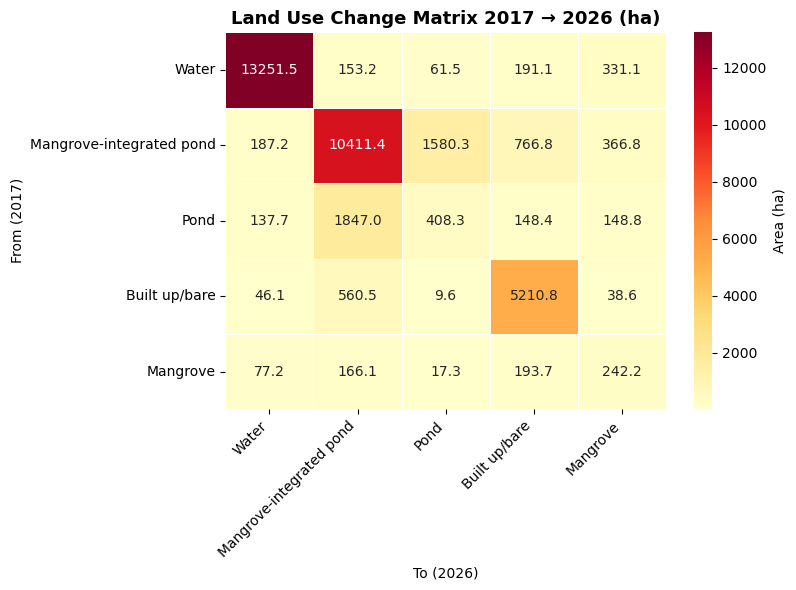

In [14]:
#Visuslize as land use change matrix heatmap with sns
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matrix_by_ha.round(2),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Area (ha)"}
)

ax.set_title("Land Use Change Matrix 2017 → 2026 (ha)", fontsize=13, fontweight="bold")
ax.set_xlabel("To (2026)")
ax.set_ylabel("From (2017)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("change_matrix_heatmap.png", dpi=150)

In [15]:
change_map = np.where(
    (data17 == nodata_value) | (data26 == nodata_value), -1, 
    np.where(data17 == data26, 0, 1)) #0 means no change, 1 means change
# Encode transitions as from_class * 10 + to_class (for example, 14 is Water to Mangrove)
transition_map = np.where(
    (data17 == nodata_value) | (data26 == nodata_value),-1,
    data17 * 10 + data26)

# Isolate only pixels that changed
changed_only = np.where(data17 != data26, transition_map, 0)

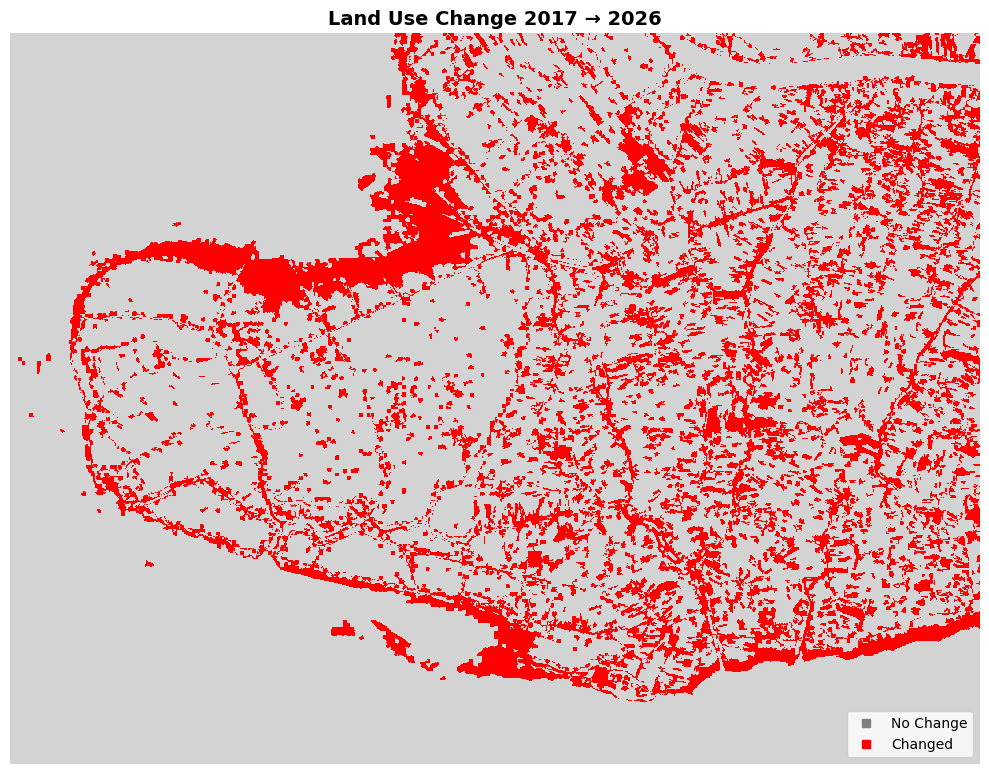

In [16]:
#Plot areas of change vs areas of no change
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(np.where(change_map == -1, np.nan, change_map), cmap=plt.cm.colors.ListedColormap(["lightgrey", "red"]), vmin=0, vmax=1,
interpolation="nearest")

ax.plot([], [], "s", color="grey", label="No Change")
ax.plot([], [], "s", color="red",   label="Changed")
ax.legend(loc="lower right", fontsize=10)

ax.set_title("Land Use Change 2017 → 2026", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()

/tmp/ipykernel_89/1621252045.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("tab20", len(transitions))


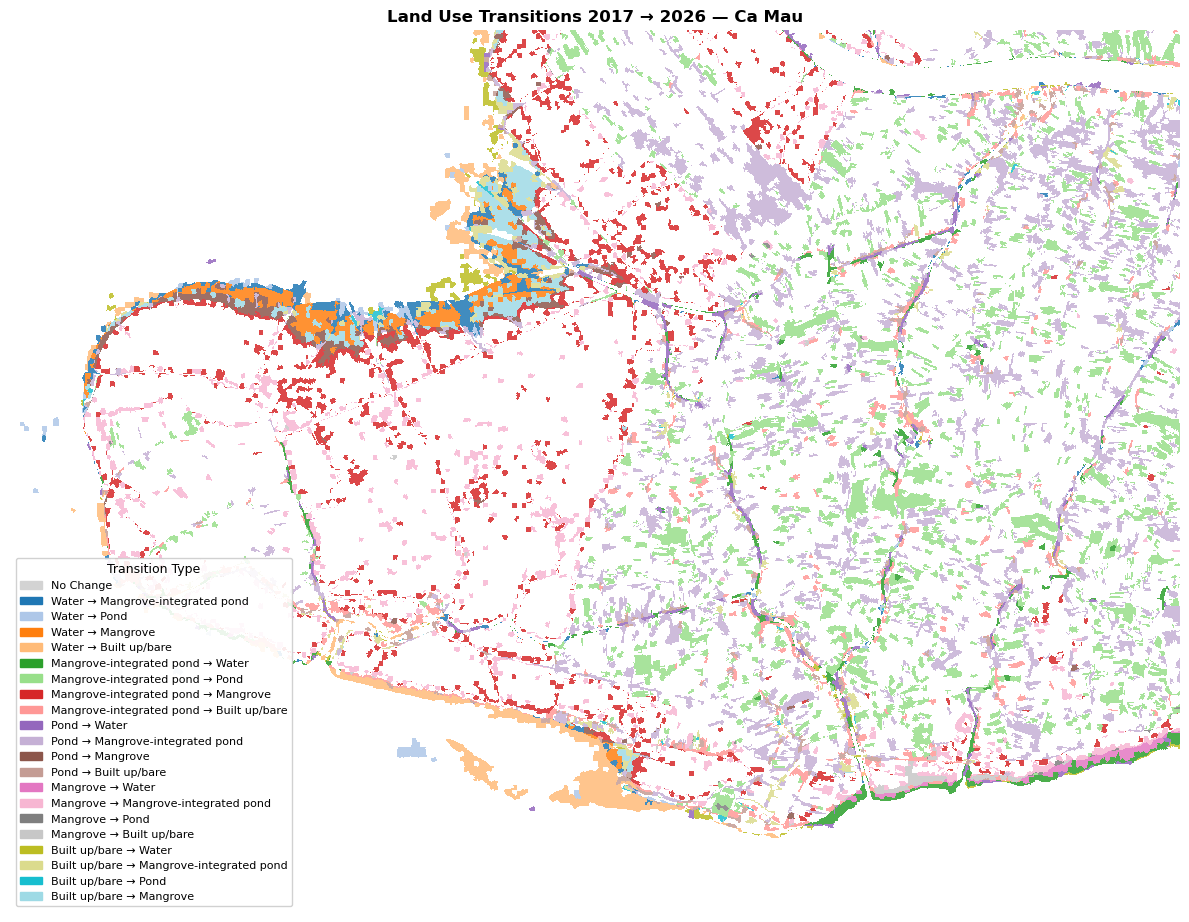

In [19]:
# Define transitions (from_id * 10 + to_id) — label only
transitions = {
    12: "Water → Mangrove-integrated pond",
    13: "Water → Pond",
    14: "Water → Mangrove",
    15: "Water → Built up/bare",
    21: "Mangrove-integrated pond → Water",
    23: "Mangrove-integrated pond → Pond",
    24: "Mangrove-integrated pond → Mangrove",
    25: "Mangrove-integrated pond → Built up/bare",
    31: "Pond → Water",
    32: "Pond → Mangrove-integrated pond",
    34: "Pond → Mangrove",
    35: "Pond → Built up/bare",
    41: "Mangrove → Water",
    42: "Mangrove → Mangrove-integrated pond",
    43: "Mangrove → Pond",
    45: "Mangrove → Built up/bare",
    51: "Built up/bare → Water",
    52: "Built up/bare → Mangrove-integrated pond",
    53: "Built up/bare → Pond",
    54: "Built up/bare → Mangrove"}

# Auto-assign a distinct color to each transition, uses RGBA tuples https://matplotlib.org/stable/users/explain/colors/colors.html
colormap = cm.get_cmap("tab20", len(transitions))
transition_colors = {
    code: colormap(i) for i, code in enumerate(transitions)
}

# Build labelled transition layer
transition_labels = np.zeros_like(data17, dtype=int)
for code in transitions:
    transition_labels[changed_only == code] = code

# Plot with gray base later
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(np.zeros_like(data17), cmap="Greys", alpha=0.2) 

legend_patches = [mpatches.Patch(color="lightgrey", label="No Change")]

for code, label in transitions.items():
    mask = transition_labels == code
    color = transition_colors[code]
    overlay = np.zeros((*data17.shape, 4), dtype=float) 
    overlay[mask] = (*color[:3], 0.85)
    ax.imshow(overlay, interpolation="nearest")
    legend_patches.append(mpatches.Patch(color=color, label=label))

ax.legend(
    handles=legend_patches, loc="lower left", fontsize=8, framealpha=0.9,title="Transition Type", title_fontsize=9)
ax.set_title("Land Use Transitions 2017 → 2026 — Ca Mau", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("change_map_transitions.png", dpi=150, bbox_inches="tight")

In [24]:
#Create KMZ file to look at Google Earth for "groundtruthing"- written with Claude help bc idk how to deal with KMZ

# ── SAVE AS GEOTIFF ────────────────────────────────────────────────────────
with rasterio.open(
    "change_map_transitions.tif", "w",
    driver="GTiff",
    height=colored.shape[0],
    width=colored.shape[1],
    count=4,
    dtype=rasterio.uint8,
    crs=camau2017_classified_ds.GetProjectionRef(),
    transform=Affine.from_gdal(*gt)        # ← fix here
) as dst:
    for i in range(4):
        dst.write(colored[:, :, i], i + 1)

# ── CONVERT TO KMZ ────────────────────────────────────────────────────────
subprocess.run([
    "gdal_translate",
    "-of", "KMLSUPEROVERLAY",
    "-co", "FORMAT=PNG",
    "transition_colored.tif",
    "transition_map.kmz"
], check=True)

print("Saved to transition_map.kmz")

Input file size is 2202, 1660
.60...70...80...90...100 - done.
Saved to transition_map.kmz
